In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
from tqdm.auto import tqdm
import pyro
import pyro.distributions as dist
from torch.distributions import constraints
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam
import math




# Установка случайного сида для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# data

сначала я удалил все дубликаты, потом заметил что одним и тем же строкам, соответствовала разная сигма, их объединил в среднее

In [6]:
df = pd.read_csv('../data/data_clear.csv')
df

,T.K,t.h,Th,C,Cr,Co,Mo,W,Al,Ti,...,S,Si,Mn,P,Hf,Cu,Ge,Ga,Ni,"Sigma, Mpa"
0,294.260,120.0,NaN,0.10,9.0,20.0,1.0,5.5,5.50,NaN,...,NaN,0.01,NaN,NaN,0.20,NaN,NaN,NaN,51.030,1186.587680
1,773.150,100.0,0.0,0.00,5.0,0.0,2.0,5.0,5.50,1.0,...,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,69.500,880.000000
2,773.150,1000.0,0.0,0.00,10.0,5.0,1.5,7.0,5.00,1.4,...,0.0,0.00,0.0,0.0,0.10,0.0,0.0,0.0,62.000,154.000000
3,823.150,100.0,0.0,0.15,9.0,10.0,0.0,10.0,5.50,1.5,...,0.0,0.00,0.0,0.0,1.20,0.0,0.0,0.0,58.085,880.000000
4,866.480,4.0,0.0,NaN,19.0,0.0,3.0,NaN,0.50,0.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.000,1151.424419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,1473.150,65.0,NaN,NaN,4.2,8.0,1.0,4.0,5.40,1.0,...,NaN,0.10,NaN,NaN,0.25,NaN,NaN,NaN,62.650,80.000000
1045,1473.150,100.0,0.0,0.06,16.0,5.0,3.0,0.0,3.50,3.5,...,0.0,0.00,0.0,0.0,1.00,0.0,0.0,0.0,62.910,57.678889
1046,1473.150,500.0,0.0,0.03,2.0,16.5,2.0,6.0,5.55,0.0,...,0.0,0.00,0.0,0.0,0.15,0.0,0.0,0.0,48.570,28.337500
1047,1560.928,90.0,NaN,NaN,10.0,5.0,NaN,4.0,5.00,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.500,248.211252


In [7]:
mass = '232,03806	12,011	51,9961	58,933194	95,95	183,84	26,9815385	47,867	92,90637	10,81	55,845	88,90584	91,224	180,94788	186,207	101,07	50,9415	140,116	138,90547	32,06	28,085	54,938044	24,305	30,973761998	178,49	107,8682	63,546	208,9804	207,2	192,22	72,63	69,723	58,6934'.replace(',', '.').split()
element = 'Th	C	Cr	Co	Mo	W	Al	Ti	Nb	B	Fe	Y	Zr	Ta	Re	Ru	V	Ce	La	S	Si	Mn	Mg	P	Hf	Ag	Cu	Bi	Pb	Ir	Ge	Ga	Ni'.split()
atom_mass = dict(zip(element, mass))

In [8]:
atom_mass['Ni']

'58.6934'

In [9]:
# for elem in df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list():
#     df[elem] = df[elem] / float(atom_mass[elem])
# df['sum'] = df[df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list()].sum(axis=1, skipna=True)
df['PLM'] = df['T.K'] * (20 + np.log10(df['t.h'])) * 1e-5

# cols = df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns
# df.loc[:, cols] = df.loc[:, cols].div(df['sum'], axis=0)
# df.loc[:, cols] = df.loc[:, cols].div(df['Ni'], axis=0)



df = df.fillna(0)

df = df.drop(columns=['T.K', 't.h'])

df

,Th,C,Cr,Co,Mo,W,Al,Ti,Nb,B,...,Si,Mn,P,Hf,Cu,Ge,Ga,Ni,"Sigma, Mpa",PLM
0,0.0,0.10,9.0,20.0,1.0,5.5,5.50,0.0,0.0,0.010,...,0.01,0.0,0.0,0.20,0.0,0.0,0.0,51.030,1186.587680,0.064970
1,0.0,0.00,5.0,0.0,2.0,5.0,5.50,1.0,0.0,0.000,...,0.00,0.0,0.0,0.00,0.0,0.0,0.0,69.500,880.000000,0.170093
2,0.0,0.00,10.0,5.0,1.5,7.0,5.00,1.4,0.0,0.000,...,0.00,0.0,0.0,0.10,0.0,0.0,0.0,62.000,154.000000,0.177825
3,0.0,0.15,9.0,10.0,0.0,10.0,5.50,1.5,0.0,0.015,...,0.00,0.0,0.0,1.20,0.0,0.0,0.0,58.085,880.000000,0.181093
4,0.0,0.00,19.0,0.0,3.0,0.0,0.50,0.9,5.1,0.000,...,0.00,0.0,0.0,0.00,0.0,0.0,0.0,53.000,1151.424419,0.178513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,0.0,0.00,4.2,8.0,1.0,4.0,5.40,1.0,0.0,0.000,...,0.10,0.0,0.0,0.25,0.0,0.0,0.0,62.650,80.000000,0.321337
1045,0.0,0.06,16.0,5.0,3.0,0.0,3.50,3.5,0.0,0.015,...,0.00,0.0,0.0,1.00,0.0,0.0,0.0,62.910,57.678889,0.324093
1046,0.0,0.03,2.0,16.5,2.0,6.0,5.55,0.0,0.0,0.000,...,0.00,0.0,0.0,0.15,0.0,0.0,0.0,48.570,28.337500,0.334390
1047,0.0,0.00,10.0,5.0,0.0,4.0,5.00,1.5,0.0,0.000,...,0.00,0.0,0.0,0.00,0.0,0.0,0.0,62.500,248.211252,0.342690


In [10]:

def log_transform_target(sigma):
    sigma = np.asarray(sigma, dtype=np.float64)
    return -np.log10(sigma)

def inverse_log_transform(y):
    y = np.asarray(y, dtype=np.float64)
    return 10.0 ** (-y)

def calculate_mse(y_pred, y_true):
    """Вычисление MSE (Mean Squared Error)"""
    return torch.mean((y_pred - y_true) ** 2).item()

def calculate_rmse_absolute(sigma_pred, sigma_real):
    """
    Вычисление RMSE для физических значений σ (MPa)
    Корень из среднего квадрата абсолютных ошибок
    """
    mse = torch.mean((sigma_pred - sigma_real) ** 2).item()
    return np.sqrt(mse)

def calculate_rmse_relative(sigma_pred, sigma_real):
    """
    Вычисление RMSE согласно формуле (6) из статьи.
    Это относительная ошибка (Root Mean Square Relative Error)
    """
    epsilon = 1e-8
    relative_error = (sigma_pred - sigma_real) / (sigma_real.abs() + epsilon)
    mse_relative = torch.mean(relative_error ** 2).item()
    return np.sqrt(mse_relative)

def calculate_metrics_np(pred, real):
    eps = 1e-8
    # Абсолютная RMSE
    rmse_abs = np.sqrt(np.mean((pred - real) ** 2))
    
    # Относительная RMSE (Формула 6 из статьи)
    rel_err = (pred - real) / (real + eps)
    rmse_rel = np.sqrt(np.mean(rel_err ** 2))
    
    # MAPE
    mape = np.mean(np.abs(rel_err)) * 100
    
    # R²
    ss_res = np.sum((real - pred) ** 2)
    ss_tot = np.sum((real - np.mean(real)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return rmse_abs, rmse_rel, mape, r2


# NN

In [11]:
class MLPRegressorNet(nn.Module):
    """
    Обычная MLP-сеть для регрессии.
    Байесовская регуляризация будет добавлена отдельно в Pyro-модели.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim=30,
        output_dim: int = 1,
        activation: str = "tanh"
    ):
        super().__init__()

        if activation == "tanh":
            act_cls = nn.Tanh()
        elif activation == "relu":
            act_cls = nn.ReLU()
        elif activation == "silu":
            act_cls = nn.SiLU()
        elif activation == "gelu":
            act_cls = nn.GELU()
        elif activation == "elu":
            act_cls = nn.ELU()
        else:
            raise ValueError(f"Unknown activation: {activation}")


        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            act_cls,
            nn.Linear(hidden_dim, output_dim),
        )

        self.reset_parameters()

    def reset_parameters(self):
        """
        Аккуратная инициализация весов.
        Для tanh обычно хорошо работает Xavier.
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# pyro

In [12]:
import torch
import torch.nn as nn

import pyro
import pyro.distributions as dist

from torch.func import functional_call


from pyro.infer.autoguide import AutoLowRankMultivariateNormal



In [13]:
def _site_name(prefix: str, name: str) -> str:
    """
    Pyro sample site names лучше делать без точек.
    Например: layers.0.weight -> param__layers__0__weight
    """
    return prefix + "__" + name.replace(".", "__")

def _call_functional(net: nn.Module, params: dict, buffers: dict, X: torch.Tensor):
    """
    Совместимость с torch.func.functional_call и старым stateless.functional_call.
    """
    try:
        # torch.func.functional_call
        return functional_call(net, (params, buffers), (X,))
    except TypeError:
        # torch.nn.utils.stateless.functional_call
        state = {}
        state.update(params)
        state.update(buffers)
        return functional_call(net, state, (X,))


In [14]:
def make_studentt_brann_pyro_model(
    net: nn.Module,
    alpha_prior_shape: float = 1.0,
    alpha_prior_rate: float = 10.0,
    beta_prior_shape: float = 2.0,
    beta_prior_rate: float = 0.1,
    weight_df: float = 3.0,
    obs_df: float = 4.0,
    regularize_bias: bool = True,
    student_t_likelihood: bool = True,
):
    """
    Bayesian Regularized ANN через pyro.sample.

    Отличие от вашей MAP-версии:
    - веса сети теперь latent variables;
    - alpha и beta тоже latent variables;
    - вместо pyro.factor используется pyro.sample;
    - для весов используется StudentT prior;
    - для наблюдений можно использовать StudentT likelihood.

    net:
        torch.nn.Module, например MLPRegressorNet.

    alpha:
        precision prior для весов.
        Чем больше alpha, тем сильнее сжатие весов к нулю.

    beta:
        precision шума наблюдений.
        Чем больше beta, тем меньше scale шума.

    weight_df:
        число степеней свободы Student-t prior для весов.

    obs_df:
        число степеней свободы Student-t likelihood.

    regularize_bias:
        регуляризовать ли bias-параметры.
        Если False, bias будут оптимизироваться как pyro.param без prior.
    """

    def model(X, y=None):
        device = X.device
        dtype = X.dtype

        alpha_prior_shape_t = torch.tensor(
            alpha_prior_shape, device=device, dtype=dtype
        )
        alpha_prior_rate_t = torch.tensor(
            alpha_prior_rate, device=device, dtype=dtype
        )

        beta_prior_shape_t = torch.tensor(
            beta_prior_shape, device=device, dtype=dtype
        )
        beta_prior_rate_t = torch.tensor(
            beta_prior_rate, device=device, dtype=dtype
        )

        weight_df_t = torch.tensor(weight_df, device=device, dtype=dtype)
        obs_df_t = torch.tensor(obs_df, device=device, dtype=dtype)

        # alpha ~ Gamma(...)
        alpha = pyro.sample(
            "alpha",
            dist.Gamma(alpha_prior_shape_t, alpha_prior_rate_t)
        )

        # beta ~ Gamma(...)
        beta = pyro.sample(
            "beta",
            dist.Gamma(beta_prior_shape_t, beta_prior_rate_t)
        )

        sigma_w = torch.rsqrt(alpha)
        sigma_y = torch.rsqrt(beta)

        sampled_params = {}

        for name, param in net.named_parameters():
            param = param.to(device=device, dtype=dtype)

            is_weight = "weight" in name
            is_bias = "bias" in name

            should_regularize = is_weight or (regularize_bias and is_bias)

            if should_regularize:
                site = _site_name("param", name)

                prior = dist.StudentT(
                    df=weight_df_t,
                    loc=torch.zeros((), device=device, dtype=dtype),
                    scale=sigma_w,
                ).expand(param.shape).to_event(param.dim())

                sampled_params[name] = pyro.sample(site, prior)

            else:
                # Например, если regularize_bias=False.
                # Тогда bias остается trainable параметром, но без prior.
                site = _site_name("unreg_param", name)

                sampled_params[name] = pyro.param(
                    site,
                    param.detach().clone()
                )

        buffers = {}

        for name, buffer in net.named_buffers():
            if buffer.is_floating_point():
                buffers[name] = buffer.to(device=device, dtype=dtype)
            else:
                buffers[name] = buffer.to(device=device)

        # Функциональный вызов сети с sampled weights
        mu = _call_functional(net, sampled_params, buffers, X)

        pyro.deterministic("mu", mu)

        # Likelihood
        if student_t_likelihood:
            obs_dist = dist.StudentT(
                df=obs_df_t,
                loc=mu,
                scale=sigma_y,
            )
        else:
            obs_dist = dist.Normal(
                loc=mu,
                scale=sigma_y,
            )

        # Если output имеет форму [N, D], то D делаем event dimension.
        # Если output [N], то to_event не нужен.
        if mu.dim() > 1:
            obs_dist = obs_dist.to_event(mu.dim() - 1)

        with pyro.plate("data", X.shape[0]):
            pyro.sample("obs", obs_dist, obs=y)

    return model


# train

In [15]:
import torch
import pyro

from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import ClippedAdam
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer.autoguide.initialization import init_to_value


In [16]:
def _site_name(prefix: str, name: str) -> str:
    return prefix + "__" + name.replace(".", "__")

def to_tensor(x, device="cpu"):
    if isinstance(x, torch.Tensor):
        return x.float().to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)


def predict_map_brann(net, X, device="cpu"):
    X = to_tensor(X, device)

    net.eval()

    with torch.no_grad():
        pred = net(X)

    return pred.detach().cpu().numpy()

def _align_y_shape_to_net(net, X, y):
    """
    Приводит y к форме выхода сети.

    Например:
    - если net(X) имеет форму [N, 1], а y имеет форму [N],
      то делаем y -> [N, 1]
    - если net(X) имеет форму [N], а y имеет форму [N, 1],
      то делаем y -> [N]
    """
    with torch.no_grad():
        mu = net(X[: min(4, X.shape[0])])

    # net возвращает [N], y = [N, 1] -> [N]
    if mu.dim() == 1 and y.dim() == 2 and y.shape[-1] == 1:
        y = y.squeeze(-1)

    # net возвращает [N, 1], y = [N] -> [N, 1]
    if mu.dim() == 2 and mu.shape[-1] == 1 and y.dim() == 1:
        y = y.unsqueeze(-1)

    return y



In [17]:
def train_studentt_brann(
    net,
    X_train,
    y_train,
    num_steps: int,
    lr: float,


    alpha_init: float = 0.1,
    beta_init: float = 20.0,

    alpha_prior_shape: float = 1.0,
    alpha_prior_rate: float = 10.0,
    beta_prior_shape: float = 2.0,
    beta_prior_rate: float = 0.1,

    weight_df: float = 3.0,
    obs_df: float = 4.0,

    regularize_bias: bool = True,
    student_t_likelihood: bool = True,

    # параметры AutoLowRankMultivariateNormal
    rank: int = 20,
    init_scale: float = 0.03,

    clip_norm: float = 10.0,
    device: str = "cpu",
    seed: int | None = None,

    verbose: bool = False,
    print_every: int = 100,
):
    """
    Обучение Bayesian Regularized ANN через SVI.

    В отличие от MAP-версии:
    - веса сети являются latent variables через pyro.sample;
    - alpha и beta являются latent variables через pyro.sample;
    - posterior аппроксимируется AutoLowRankMultivariateNormal.

    Возвращает словарь fit, который нужен для predict.
    """

    if seed is not None:
        pyro.set_rng_seed(seed)
        torch.manual_seed(seed)

    pyro.clear_param_store()

    X_train = to_tensor(X_train, device)
    y_train = to_tensor(y_train, device)

    net.to(device)
    net.train()

    y_train = _align_y_shape_to_net(net, X_train, y_train)

    model = make_studentt_brann_pyro_model(
        net=net,
        alpha_prior_shape=alpha_prior_shape,
        alpha_prior_rate=alpha_prior_rate,
        beta_prior_shape=beta_prior_shape,
        beta_prior_rate=beta_prior_rate,
        weight_df=weight_df,
        obs_df=obs_df,
        regularize_bias=regularize_bias,
        student_t_likelihood=student_t_likelihood,
    )

    # Начальные значения для autoguide.
    # Это заменяет смысл alpha_init/beta_init из MAP-версии.
    init_values = {
        "alpha": torch.tensor(alpha_init, device=device, dtype=X_train.dtype),
        "beta": torch.tensor(beta_init, device=device, dtype=X_train.dtype),
    }

    # Инициализируем posterior весов около текущих весов net.
    for name, param in net.named_parameters():
        is_weight = "weight" in name
        is_bias = "bias" in name

        should_regularize = is_weight or (regularize_bias and is_bias)

        if should_regularize:
            site = _site_name("param", name)
            init_values[site] = param.detach().clone().to(device)

    guide = AutoLowRankMultivariateNormal(
        model,
        rank=rank,
        init_scale=init_scale,
        init_loc_fn=init_to_value(values=init_values),
    )

    optimizer = ClippedAdam({
        "lr": lr,
        "clip_norm": clip_norm,
    })

    svi = SVI(
        model=model,
        guide=guide,
        optim=optimizer,
        loss=Trace_ELBO(),
    )

    n = X_train.shape[0]
    losses = []

    for step in range(num_steps):
        loss = svi.step(X_train, y_train) / n
        losses.append(loss)

        if verbose and step % print_every == 0:
            print(f"step={step:05d} loss={loss:.6f}")

    fit = {
        "net": net,
        "model": model,
        "guide": guide,
        "losses": losses,
        "device": device,
        "regularize_bias": regularize_bias,
        "student_t_likelihood": student_t_likelihood,
    }

    return fit


# predict

In [18]:
def predict_studentt_brann(
    fit,
    X,
    num_samples: int = 500,
    device: str | None = None,
    return_samples: bool = False,
    return_obs: bool = False,
    quantiles: tuple[float, float] = (0.05, 0.95),
    squeeze_last_dim: bool = True,
):
    """
    Posterior predictive для Bayesian BRANN.

    Возвращает словарь:
    {
        "mean": posterior mean по mu,
        "std": posterior std по mu,
        "q_low": нижний квантиль по mu,
        "q_high": верхний квантиль по mu,
        "alpha_mean": posterior mean alpha,
        "beta_mean": posterior mean beta,
        optionally "mu_samples",
        optionally "obs_samples",
    }

    mu_samples:
        неопределенность модели, без наблюдательного шума.

    obs_samples:
        posterior predictive с учетом шума наблюдений.
    """

    net = fit["net"]
    model = fit["model"]
    guide = fit["guide"]

    if device is None:
        device = fit.get("device", "cpu")

    X = to_tensor(X, device)

    net.to(device)
    net.eval()

    return_sites = ["mu", "alpha", "beta"]

    if return_obs:
        return_sites.append("obs")

    predictive = Predictive(
        model=model,
        guide=guide,
        num_samples=num_samples,
        return_sites=tuple(return_sites),
    )

    with torch.no_grad():
        samples = predictive(X)

    mu_samples = samples["mu"]

    mu_mean = mu_samples.mean(dim=0)
    mu_std = mu_samples.std(dim=0)

    q_low, q_high = quantiles
    mu_q_low = torch.quantile(mu_samples, q_low, dim=0)
    mu_q_high = torch.quantile(mu_samples, q_high, dim=0)

    alpha_samples = samples["alpha"]
    beta_samples = samples["beta"]

    result = {
        "mean": mu_mean,
        "std": mu_std,
        "q_low": mu_q_low,
        "q_high": mu_q_high,
        "alpha_mean": alpha_samples.mean(dim=0),
        "beta_mean": beta_samples.mean(dim=0),
        "alpha_samples": alpha_samples,
        "beta_samples": beta_samples,
    }

    if return_samples:
        result["mu_samples"] = mu_samples

    if return_obs:
        obs_samples = samples["obs"]

        result["obs_mean"] = obs_samples.mean(dim=0)
        result["obs_std"] = obs_samples.std(dim=0)
        result["obs_q_low"] = torch.quantile(obs_samples, q_low, dim=0)
        result["obs_q_high"] = torch.quantile(obs_samples, q_high, dim=0)

        if return_samples:
            result["obs_samples"] = obs_samples

    # Переводим в numpy
    numpy_result = {}

    for key, value in result.items():
        if isinstance(value, torch.Tensor):
            value = value.detach().cpu()

            if squeeze_last_dim and value.dim() > 0 and value.shape[-1] == 1:
                value = value.squeeze(-1)

            numpy_result[key] = value.numpy()
        else:
            numpy_result[key] = value

    return numpy_result

def predict_studentt_brann_like_map(
    fit,
    X,
    num_samples: int = 500,
    device: str | None = None,
    squeeze_last_dim: bool = True,
):
    """
    Возвращает один вектор предсказаний, как старый predict_map_brann.

    Берет posterior mean по mu, то есть среднее предсказание сети
    без добавления наблюдательного шума.

    Return:
        numpy array shape [N]
    """

    net = fit["net"]
    model = fit["model"]
    guide = fit["guide"]

    if device is None:
        device = fit.get("device", "cpu")

    X = to_tensor(X, device)

    net.to(device)
    net.eval()

    predictive = Predictive(
        model=model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("mu",),
    )

    with torch.no_grad():
        samples = predictive(X)

    mu_samples = samples["mu"]          # [num_samples, N] или [num_samples, N, 1]

    y_pred = mu_samples.mean(dim=0)     # [N] или [N, 1]

    y_pred = y_pred.detach().cpu()

    if squeeze_last_dim and y_pred.dim() > 0 and y_pred.shape[-1] == 1:
        y_pred = y_pred.squeeze(-1)

    return y_pred.numpy()


In [19]:
def regression_metrics_sigma(sigma_true, sigma_pred, eps=1e-8):
    sigma_true = np.asarray(sigma_true).ravel()
    sigma_pred = np.asarray(sigma_pred).ravel()

    if not np.isfinite(sigma_true).all():
        raise ValueError("sigma_true contains nan/inf")

    if not np.isfinite(sigma_pred).all():
        raise ValueError("sigma_pred contains nan/inf")

    denom = np.maximum(np.abs(sigma_true), eps)

    rmse_abs = np.sqrt(np.mean((sigma_pred - sigma_true) ** 2))
    mae_abs = np.mean(np.abs(sigma_pred - sigma_true))

    rmse_rel = np.sqrt(
        np.mean(((sigma_pred - sigma_true) / denom) ** 2)
    )

    mape = np.mean(
        np.abs((sigma_pred - sigma_true) / denom)
    ) * 100

    ss_res = np.sum((sigma_true - sigma_pred) ** 2)
    ss_tot = np.sum((sigma_true - np.mean(sigma_true)) ** 2)

    if ss_tot < eps:
        r2 = np.nan
    else:
        r2 = 1.0 - ss_res / ss_tot

    return {
        "rmse_abs": rmse_abs,
        "mae_abs": mae_abs,
        "rmse_rel": rmse_rel,
        "mape": mape,
        "r2": r2,
    }



def get_alpha_beta():
    return {
        "alpha": pyro.param("alpha").item(),
        "beta": pyro.param("beta").item(),
        "sigma_noise_scaled": 1.0 / math.sqrt(pyro.param("beta").item())
    }

In [20]:
def get_map_brann_params():
    """
    Возвращает alpha, beta и sigma_noise в нормированной шкале y.
    """

    alpha = pyro.param("alpha").item()
    beta = pyro.param("beta").item()

    sigma_noise = 1.0 / math.sqrt(beta)

    return {
        "alpha": alpha,
        "beta": beta,
        "sigma_noise_scaled": sigma_noise,
    }


In [21]:
def get_noise_std_original_scale(y_scaler):
    """
    y_scaler — твой StandardScaler для target.
    """
    beta = pyro.param("beta").item()
    sigma_noise_scaled = 1.0 / math.sqrt(beta)

    sigma_noise_original = sigma_noise_scaled * y_scaler.scale_[0]

    return sigma_noise_original


In [22]:
import numpy as np
import torch
from pyro.infer import Predictive


def inspect_alpha_beta(
    fit,
    X_ref,
    num_samples: int = 2000,
    device: str | None = None,
):
    """
    Сэмплирует posterior alpha и beta из guide.

    alpha — precision весов.
    beta  — precision шума наблюдений.

    sigma_w = 1 / sqrt(alpha)
    sigma_y = 1 / sqrt(beta)
    """

    model = fit["model"]
    guide = fit["guide"]

    if device is None:
        device = fit.get("device", "cpu")

    X_ref = to_tensor(X_ref, device)

    # Можно взять только 1-10 объектов, потому что alpha/beta не зависят от N.
    X_ref = X_ref[: min(10, X_ref.shape[0])]

    predictive = Predictive(
        model=model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("alpha", "beta"),
    )

    with torch.no_grad():
        samples = predictive(X_ref)

    alpha = samples["alpha"].detach().cpu().numpy().reshape(-1)
    beta = samples["beta"].detach().cpu().numpy().reshape(-1)

    sigma_w = 1.0 / np.sqrt(alpha)
    sigma_y = 1.0 / np.sqrt(beta)

    def summary(arr):
        return {
            "mean": float(np.mean(arr)),
            "std": float(np.std(arr)),
            "q05": float(np.quantile(arr, 0.05)),
            "median": float(np.quantile(arr, 0.50)),
            "q95": float(np.quantile(arr, 0.95)),
        }

    result = {
        "alpha": summary(alpha),
        "beta": summary(beta),
        "sigma_w": summary(sigma_w),
        "sigma_y": summary(sigma_y),
        "alpha_samples": alpha,
        "beta_samples": beta,
        "sigma_w_samples": sigma_w,
        "sigma_y_samples": sigma_y,
    }

    return result


# main

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

target_col = 'Sigma, Mpa'
sigma = np.asarray(df[target_col], dtype=np.float32).reshape(-1, 1)
y = np.asarray(log_transform_target(sigma), dtype=np.float32).reshape(-1, 1).astype("float32")
X = df.copy().drop(columns=[target_col]).to_numpy().astype("float32")
print(X, y, sigma)

# X_temp, X_test, y_temp, y_test, sigma_temp, sigma_test = train_test_split(
#     X,
#     y,
#     sigma,
#     test_size=0.1,
#     random_state=42,
#     shuffle=True
# )

y_bins = pd.qcut(y.ravel(), q=10, labels=False, duplicates="drop")

X_temp, X_test, y_temp, y_test, sigma_temp, sigma_test = train_test_split(
    X,
    y,
    sigma,
    test_size=0.1,
    random_state=42,
    shuffle=True,
    stratify=y_bins
)

scaler_X = RobustScaler()
scaler_y = RobustScaler()


X_scaled = scaler_X.fit_transform(X_temp).astype("float32") # ???
y_scaled = scaler_y.fit_transform(y_temp).astype("float32").reshape(-1,1)



X_test_scaled = scaler_X.transform(X_test).astype("float32")
y_test_scaled = scaler_y.transform(y_test).astype("float32").reshape(-1,1)

# X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.25, random_state=42)



[[0.0000000e+00 1.0000000e-01 9.0000000e+00 ... 0.0000000e+00
  5.1029999e+01 6.4970195e-02]
 [0.0000000e+00 0.0000000e+00 5.0000000e+00 ... 0.0000000e+00
  6.9500000e+01 1.7009300e-01]
 [0.0000000e+00 0.0000000e+00 1.0000000e+01 ... 0.0000000e+00
  6.2000000e+01 1.7782450e-01]
 ...
 [0.0000000e+00 2.9999999e-02 2.0000000e+00 ... 0.0000000e+00
  4.8570000e+01 3.3438987e-01]
 [0.0000000e+00 0.0000000e+00 1.0000000e+01 ... 0.0000000e+00
  6.2500000e+01 3.4268993e-01]
 [0.0000000e+00 0.0000000e+00 1.0000000e+01 ... 0.0000000e+00
  6.7500000e+01 3.3967763e-01]] [[-3.0742998]
 [-2.9444826]
 [-2.1875207]
 ...
 [-1.4523616]
 [-2.3948214]
 [-2.3948214]] [[1186.5876 ]
 [ 880.     ]
 [ 154.     ]
 ...
 [  28.3375 ]
 [ 248.21126]
 [ 248.21126]]


In [24]:
y_temp_bins = pd.qcut(y_temp.ravel(), q=10, labels=False, duplicates="drop")

X_train_opt, X_val_opt, y_train_opt, y_val_opt, sigma_train_opt, sigma_val_opt = train_test_split(
    X_scaled,
    y_scaled,
    sigma_temp,
    test_size=0.1,
    random_state=42,
    shuffle=True,
    stratify=y_temp_bins
)

In [25]:
input_dim = X_scaled.shape[1]


net = MLPRegressorNet(
    input_dim=input_dim,
    hidden_dim=10,
    output_dim=1,
    activation="tanh"
)

fit = train_studentt_brann(
    net=net,
    X_train=X_train_opt,
    y_train=y_train_opt,
    num_steps=5001,
    lr=1e-3,

    alpha_init=0.1,
    beta_init=2.0,

    alpha_prior_shape=2.0,
    alpha_prior_rate=0.1,
    beta_prior_shape=2.0,
    beta_prior_rate=0.1,

    weight_df=10.0,
    obs_df=4.0,

    regularize_bias=True,
    student_t_likelihood=True,

    rank=20,
    init_scale=0.03,

    clip_norm=10.0,
    seed=42,

    verbose=True,
    print_every=500,

    device=device
)


step=00000 loss=2.653219
step=00500 loss=1.860009
step=01000 loss=1.394913
step=01500 loss=1.067507
step=02000 loss=0.723765
step=02500 loss=0.479041
step=03000 loss=0.241303
step=03500 loss=0.158935
step=04000 loss=0.149155
step=04500 loss=0.058886
step=05000 loss=0.051455


In [26]:
y_pred_scaled = predict_studentt_brann_like_map(
    fit=fit,
    X=X_test_scaled,
    num_samples=500,
)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


y_test_original = y_test.ravel()

ab = inspect_alpha_beta(
    fit=fit,
    X_ref=X_scaled,
    num_samples=5000,
)

print("alpha:", ab["alpha"])
print("sigma_w:", ab["sigma_w"])

print("beta:", ab["beta"])
print("sigma_y:", ab["sigma_y"])


sigma_pred = inverse_log_transform(y_pred)


mse = mean_squared_error(y_test_original, y_pred)


rrmse = calculate_rmse_relative(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))
r2 = r2_score(y_test_original, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RRMSE : {rrmse:.4f}")
print(f"R2  : {r2:.4f}")


alpha: {'mean': 10.116543769836426, 'std': 0.7412952184677124, 'q05': 8.924367904663086, 'median': 10.092883110046387, 'q95': 11.363960266113281}
sigma_w: {'mean': 0.31503593921661377, 'std': 0.011579294688999653, 'q05': 0.2966437339782715, 'median': 0.31476929783821106, 'q95': 0.33474278450012207}
beta: {'mean': 63.98109817504883, 'std': 3.36488938331604, 'q05': 58.49696350097656, 'median': 63.9566650390625, 'q95': 69.62212371826172}
sigma_y: {'mean': 0.12514814734458923, 'std': 0.0032922602258622646, 'q05': 0.11984678357839584, 'median': 0.12504233419895172, 'q95': 0.1307474821805954}
MSE: 0.0300
RRMSE : 1.8499
R2  : 0.7074


In [28]:
rmse_absolute = calculate_rmse_absolute(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))
rmse_relative = calculate_rmse_relative(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))

# MAPE (Mean Absolute Percentage Error)
# mape = torch.mean(torch.abs((torch.FloatTensor(sigma_pred) - torch.FloatTensor(sigma_test)) / 
                                # (torch.FloatTensor(sigma_test) + 1e-8))) * 100


# print(f"""{y_pred_scaled[:5]=},\n {y_pred[:5]=},\n
# {sigma_pred[:5]=}, \n{sigma_real_tensor[:5]=} \n{y_test_t[:5]=}\n""")
print(f"\nРезультаты:")
print(f"  RMSE (абсолютная): {rmse_absolute:.2f} MPa")
print(f"  RRMSE (относительная, формула 6): {rmse_relative:.4f}")
# print(f"  MAPE: {mape.item():.2f}%")
print(f"  Мин. предсказанное σ: {sigma_pred.min():.2f} MPa")
print(f"  Макс. предсказанное σ: {sigma_pred.max():.2f} MPa")
print(f"  Мин. реальный σ: {sigma_test.min():.2f} MPa")
print(f"  Макс. реальный σ: {sigma_test.max():.2f} MPa")


Результаты:
  RMSE (абсолютная): 364.18 MPa
  RRMSE (относительная, формула 6): 1.8499
  Мин. предсказанное σ: 83.15 MPa
  Макс. предсказанное σ: 1014.47 MPa
  Мин. реальный σ: 80.00 MPa
  Макс. реальный σ: 1303.11 MPa


In [29]:
print(y_pred_scaled.min(), y_pred_scaled.max())
print(y_pred.min(), y_pred.max())
print(y_test.min(), y_test.max())


-1.0160847 0.7893035
-3.0062375 -1.9198679
-3.1149807 -1.90309


In [30]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


def evaluate_regression(y_true, y_pred, name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    rrmse = rmse / np.std(y_true)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print(f"MSE   : {mse:.6f}")
    print(f"RMSE  : {rmse:.6f}")
    print(f"RRMSE : {rrmse:.6f}")
    print(f"R2    : {r2:.6f}")


In [31]:
y_pred_train_scaled = predict_studentt_brann_like_map(
    fit=fit,
    X=X_train_opt,
    num_samples=500,
)

y_pred_train = scaler_y.inverse_transform(
    y_pred_train_scaled.reshape(-1, 1)
).ravel()

evaluate_regression(y_train_opt, y_pred_train, name="TRAIN")


TRAIN
MSE   : 5.726986
RMSE  : 2.393112
RRMSE : 4.460283
R2    : -18.894127


In [32]:
y_pred_test_scaled = predict_studentt_brann_like_map(
    fit=fit,
    X=X_val_opt,
    num_samples=500,
)

y_pred_test = scaler_y.inverse_transform(
    y_pred_test_scaled.reshape(-1, 1)
).ravel()

evaluate_regression(y_val_opt, y_pred_test, name="VAL")

VAL
MSE   : 5.616895
RMSE  : 2.369999
RRMSE : 4.477867
R2    : -19.051292


In [33]:
y_pred_test_scaled = predict_studentt_brann_like_map(
    fit=fit,
    X=X_test_scaled,
    num_samples=500,
)

y_pred_test = scaler_y.inverse_transform(
    y_pred_test_scaled.reshape(-1, 1)
).ravel()

evaluate_regression(y_test, y_pred_test, name="TEST")


TEST
MSE   : 0.030030
RMSE  : 0.173293
RRMSE : 0.541413
R2    : 0.706872


In [34]:
# import seaborn as sns
# import matplotlib.pyplot as plt


# sns.histplot(y_pred, kde=True, bins=30, color='steelblue', stat='density')
# plt.title('Распределение переменной')
# plt.xlabel('Значение')
# plt.ylabel('Плотность')
# plt.grid(True, alpha=0.3)
# plt.show()

In [35]:
# eps = 100.0  # например, 50 MPa

# relative_rmse_safe = np.sqrt(
#     np.mean(((sigma_pred - sigma_test) / np.maximum(sigma_test, eps)) ** 2)
# )

# mape_safe = np.mean(
#     np.abs((sigma_pred - sigma_test) / np.maximum(sigma_test, eps))
# ) * 100

# print(f"Safe relative RMSE: {relative_rmse_safe:.4f}")
# print(f"Safe MAPE         : {mape_safe:.2f}%")

# graphic

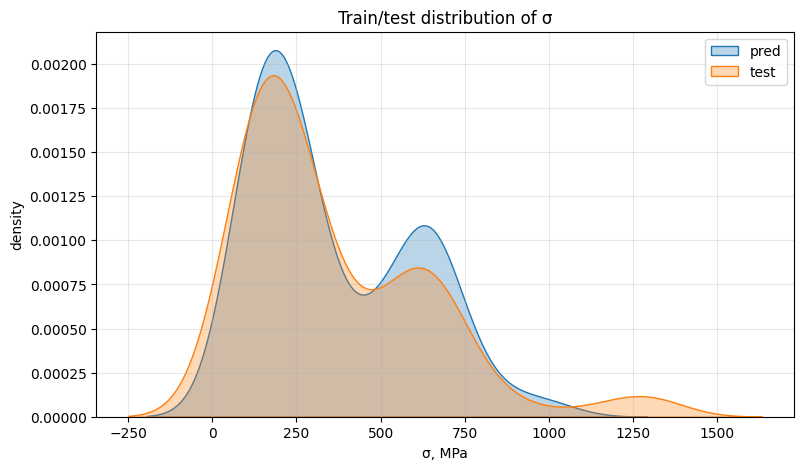

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

# sns.kdeplot(inverse_log_transform(scaler_y.inverse_transform(y_train_opt.reshape(-1, 1))).ravel(), label="train", fill=True, alpha=0.3)
# sns.kdeplot(inverse_log_transform(scaler_y.inverse_transform(y_val_opt.reshape(-1, 1))), label="val", fill=True, alpha=0.3)
# sns.kdeplot(inverse_log_transform(y_test).ravel(), label="test", fill=True, alpha=0.3)
sns.kdeplot(sigma_pred.ravel(), label="pred", fill=True, alpha=0.3)
sns.kdeplot(sigma_test.ravel(), label="test", fill=True, alpha=0.3)



plt.xlabel("σ, MPa")
plt.ylabel("density")
plt.title("Pred/test distribution of σ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [37]:
import numpy as np

sigma_pred = sigma_pred.ravel()
sigma_test = sigma_test.ravel()

rmse_original = np.sqrt(np.mean((sigma_pred - sigma_test) ** 2))

rmse_sorted = np.sqrt(
    np.mean((np.sort(sigma_pred) - np.sort(sigma_test)) ** 2)
)

print("RMSE original:", rmse_original)
print("RMSE sorted:", rmse_sorted)


RMSE original: 179.0180268540127
RMSE sorted: 75.75808499204055


In [38]:
from scipy.stats import pearsonr, spearmanr

print("Pearson:", pearsonr(sigma_test.ravel(), sigma_pred.ravel()))
print("Spearman:", spearmanr(sigma_test.ravel(), sigma_pred.ravel()))


Pearson: PearsonRResult(statistic=np.float64(0.7693912765905886), pvalue=np.float64(9.04781157109347e-22))
Spearman: SignificanceResult(statistic=np.float64(0.8532857507428938), pvalue=np.float64(6.826492000214067e-31))


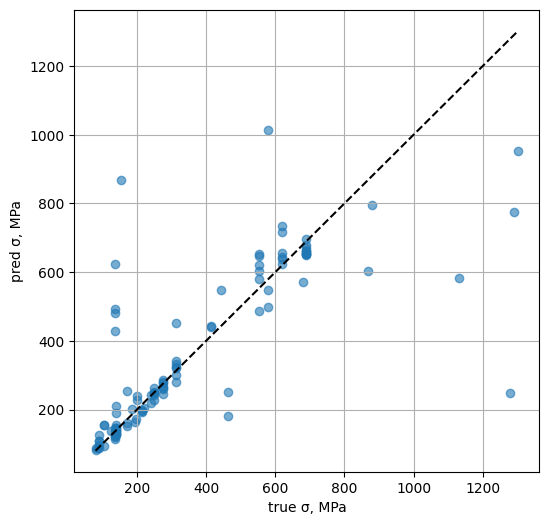

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(sigma_test, sigma_pred, alpha=0.6)
mn = min(sigma_test.min(), sigma_pred.min())
mx = max(sigma_test.max(), sigma_pred.max())
plt.plot([mn, mx], [mn, mx], "k--")
plt.xlabel("true σ, MPa")
plt.ylabel("pred σ, MPa")
plt.grid(True)
plt.show()


In [40]:
# import numpy as np
# from sklearn.model_selection import train_test_split


# bins = np.quantile(
#     sigma,
#     q=np.linspace(0, 1, 8)
# )

# # чтобы не было одинаковых границ
# bins = np.unique(bins)

# sigma_bins = np.digitize(sigma, bins[1:-1])

# X_train, X_test, sigma_train, sigma_test = train_test_split(
#     X,
#     sigma,
#     test_size=0.15,
#     random_state=42,
#     stratify=sigma_bins
# )


In [41]:
# def metrics_by_bins(sigma_true, sigma_pred):
#     bins = [
#         (0, 100),
#         (100, 300),
#         (300, 600),
#         (600, 900),
#         (900, np.inf),
#     ]

#     sigma_true = np.asarray(sigma_true).ravel()
#     sigma_pred = np.asarray(sigma_pred).ravel()

#     for low, high in bins:
#         mask = (sigma_true >= low) & (sigma_true < high)

#         if mask.sum() == 0:
#             continue

#         rmse = mean_squared_error(sigma_true[mask], sigma_pred[mask]) ** 0.5
#         mae = mean_absolute_error(sigma_true[mask], sigma_pred[mask])

#         mape_bin = np.mean(
#             np.abs((sigma_pred[mask] - sigma_true[mask]) / sigma_true[mask])
#         ) * 100

#         print(
#             f"{low:>4} - {high:<6} | "
#             f"n={mask.sum():>4} | "
#             f"RMSE={rmse:>8.2f} | "
#             f"MAE={mae:>8.2f} | "
#             f"MAPE={mape_bin:>8.2f}%"
#         )

# metrics_by_bins(sigma_test, sigma_pred)


# RF

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# обучаем на log1p(sigma)
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_scaled, y_scaled)

y_pred_scaled_rf = rf.predict(X_test_scaled)

y_pred_log_rf = scaler_y.inverse_transform(
    y_pred_scaled_rf.reshape(-1, 1)
).ravel()

mse_rf = mean_absolute_error(y_pred_log_rf, y_test)

sigma_pred_rf = inverse_log_transform(y_pred_log_rf)
sigma_pred_rf = np.clip(sigma_pred_rf, 0.0, None)

rmse_rf = mean_squared_error(sigma_test, sigma_pred_rf) ** 0.5
r2_rf = r2_score(sigma_test, sigma_pred_rf)
mape_rf = np.mean(np.abs((sigma_pred_rf - sigma_test) / sigma_test)) * 100
rrmse_fr = calculate_rmse_relative(torch.FloatTensor(sigma_pred_rf), torch.FloatTensor(sigma_test)) * 100


/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [43]:
print(f"RF MSE: {mse_rf:.2f} MPa")
print(f"RF RMSE: {rmse_rf:.2f} MPa")
print(f"RF R2  : {r2_rf:.4f}")
print(f"RF MAPE: {mape_rf:.2f}%")
print(f"RF RRMSE: {rrmse_fr:.2f}%")

print(f"Min pred σ: {sigma_pred_rf.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_rf.max():.2f} MPa")
print(f"Min true σ: {sigma_test.min():.2f} MPa")
print(f"Max true σ: {sigma_test.max():.2f} MPa")


RF MSE: 0.05 MPa
RF RMSE: 119.24 MPa
RF R2  : 0.8165
RF MAPE: 14.90%
RF RRMSE: 44.22%
Min pred σ: 78.91 MPa
Max pred σ: 1098.11 MPa
Min true σ: 80.00 MPa
Max true σ: 1303.11 MPa


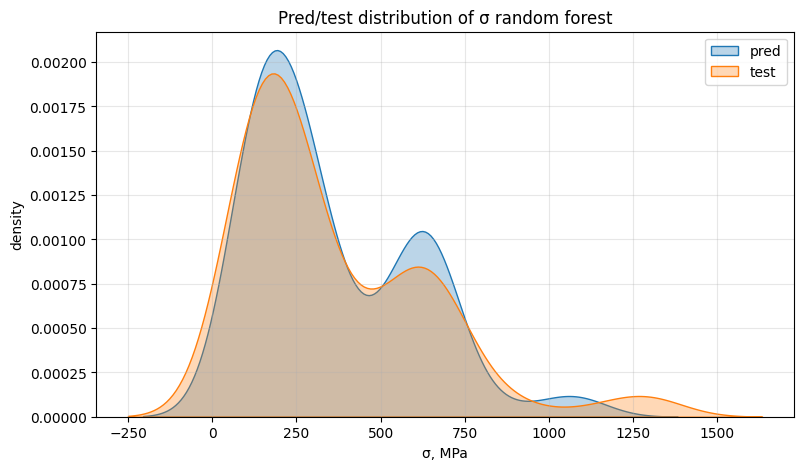

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.kdeplot(sigma_pred_rf.ravel(), label="pred", fill=True, alpha=0.3)
sns.kdeplot(sigma_test.ravel(), label="test", fill=True, alpha=0.3)



plt.xlabel("σ, MPa")
plt.ylabel("density")
plt.title("Pred/test distribution of σ random forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [45]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae = np.mean(np.abs(y_pred - y_true))
    mape = np.mean(np.abs((y_pred - y_true) / np.maximum(np.abs(y_true), 1e-8))) * 100
    return rmse, mae, mape

rmse, mae, mape = metrics(sigma_pred, sigma_test)
print("all:", rmse, mae, mape)

abs_err = np.abs(sigma_pred - sigma_test)

for q in [0.95, 0.90, 0.85]:
    thr = np.quantile(abs_err, q)
    mask = abs_err <= thr
    rmse_q, mae_q, mape_q = metrics(sigma_test[mask], sigma_pred[mask])
    print(f"without top {100*(1-q):.0f}% errors:", rmse_q, mae_q, mape_q, "n=", mask.sum())


all: 179.0180268540127 80.5597974567241 20.60088265396049
without top 5% errors: 90.07059034854818 47.79797751660947 18.650759763205556 n= 99
without top 10% errors: 53.875275910974985 33.09930581081023 11.014306946631363 n= 94
without top 15% errors: 35.76471513841155 25.560315061246584 9.898251650451007 n= 89


In [46]:
eval_df = df.loc[pd.DataFrame(X_test).index].copy()

eval_df["sigma_test"] = sigma_test
eval_df["sigma_pred"] = sigma_pred
eval_df["err"] = eval_df["sigma_pred"] - eval_df["sigma_test"]
eval_df["abs_err"] = np.abs(eval_df["err"])
eval_df["ape"] = eval_df["abs_err"] / np.maximum(np.abs(eval_df["sigma_test"]), 1e-8) * 100

cols_to_show = [
    "sigma_test",
    "sigma_pred",
    "err",
    "abs_err",
    "ape",
]

# если есть такие колонки
extra_cols = [
    "PLM",
    "T.K",
    "t.h",
]

for col in extra_cols:
    if col in eval_df.columns:
        cols_to_show.append(col)

eval_df.sort_values("abs_err", ascending=False)[cols_to_show].head(20)


,sigma_test,sigma_pred,err,abs_err,ape,PLM
101,1279.000000,248.395377,-1030.604623,1030.604623,80.578938,0.203040
15,154.000000,869.745299,715.745299,715.745299,464.769674,0.195038
78,1131.429565,583.581932,-547.847634,547.847634,48.420834,0.183389
17,1289.319580,776.621548,-512.698032,512.698032,39.765008,0.199717
73,137.000000,622.417347,485.417347,485.417347,354.319231,0.213587
55,580.000000,1014.466025,434.466025,434.466025,74.907935,0.205292
102,137.000000,491.809888,354.809888,354.809888,258.985320,0.203212
28,1303.109131,953.982368,-349.126763,349.126763,26.791828,0.179887
84,137.000000,482.116991,345.116991,345.116991,251.910212,0.188558
99,137.000000,428.465685,291.465685,291.465685,212.748675,0.202593


In [47]:
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# # X_train_np и X_test_np должны быть уже в той же scaled feature-шкале,
# # которую ты подаёшь в модель
# NN = NearestNeighbors(n_neighbors=5)
# NN.fit(X_scaled)

# d, idx = NN.kneighbors(X_test_scaled)

# eval_df["nn_dist_1"] = d[:, 0]
# eval_df["nn_idx_1"] = idx[:, 0]

# bad_idx = eval_df.sort_values("abs_err", ascending=False).head(10).index

# for i in bad_idx:
#     print("=" * 80)
#     print("TEST ROW:", i)
#     print("test:", eval_df.loc[i, "sigma_test"])
#     print("pred:", eval_df.loc[i, "sigma_pred"])
#     print("err :", eval_df.loc[i, "err"])
#     print("PLM :", eval_df.loc[i, "PLM"])

#     print("\nNearest train points:")
#     for k in range(5):
#         j = idx[i, k]
#         print(
#             f"k={k+1}, dist={d[i,k]:.4f}, "
#             f"train_sigma={y_scaled[j, 0]:.2f}"
#         )


# optuna

In [48]:
import optuna
import traceback



def objective(trial):
    input_dim = X_scaled.shape[1]

    lr = trial.suggest_float(
        "lr",
        1e-5,
        3e-3,
        log=True
    )

    alpha_init = trial.suggest_float(
        "alpha_init",
        1e-3,
        10.0,
        log=True
    )

    beta_init = trial.suggest_float(
        "beta_init",
        0.5,
        50.0,
        log=True
    )

    # Gamma prior для alpha:
    # E[alpha] = shape / rate
    alpha_prior_shape = trial.suggest_float(
        "alpha_prior_shape",
        0.5,
        10.0,
        log=True
    )

    alpha_prior_rate = trial.suggest_float(
        "alpha_prior_rate",
        0.1,
        10.0,
        log=True
    )

    # Gamma prior для beta:
    # beta — precision шума.
    # Большая beta = меньше шум.
    beta_prior_shape = trial.suggest_float(
        "beta_prior_shape",
        0.5,
        10.0,
        log=True
    )

    beta_prior_rate = trial.suggest_float(
        "beta_prior_rate",
        0.05,
        10.0,
        log=True
    )

    # Student-t prior для весов.
    # Маленький df = тяжелые хвосты = слабее штрафуются большие веса.
    # Большой df = ближе к Normal = регуляризация жестче.
    weight_df = trial.suggest_float(
        "weight_df",
        3.0,
        30.0,
        log=True
    )

    # Student-t likelihood для наблюдений.
    # Маленький obs_df делает модель робастнее к выбросам.
    obs_df = trial.suggest_float(
        "obs_df",
        3.0,
        30.0,
        log=True
    )

    regularize_bias = trial.suggest_categorical(
        "regularize_bias",
        [True, False]
    )

    # Параметры вариационного guide
    rank = trial.suggest_categorical(
        "rank",
        [5, 10, 20]
    )

    init_scale = trial.suggest_float(
        "init_scale",
        0.005,
        0.1,
        log=True
    )

    # Можно оставить фиксированными, как у вас было
    net = MLPRegressorNet(
        input_dim=input_dim,
        hidden_dim=10,
        activation="tanh"
    )

    try:
        fit = train_studentt_brann(
            net=net,
            X_train=X_train_opt,
            y_train=y_train_opt,

            num_steps=10000,
            lr=lr,

            alpha_init=alpha_init,
            beta_init=beta_init,

            alpha_prior_shape=alpha_prior_shape,
            alpha_prior_rate=alpha_prior_rate,

            beta_prior_shape=beta_prior_shape,
            beta_prior_rate=beta_prior_rate,

            weight_df=weight_df,
            obs_df=obs_df,

            regularize_bias=regularize_bias,
            student_t_likelihood=True,

            rank=rank,
            init_scale=init_scale,

            clip_norm=10.0,
            device="cpu",
            seed=42,

            verbose=False,
            print_every=500,
        )

        # Предсказание как раньше: один вектор [N],
        # но теперь это posterior mean по mu.
        y_pred_val_scaled = predict_studentt_brann_like_map(
            fit=fit,
            X=X_val_opt,
            num_samples=300,
            device="cpu",
        )

        y_pred_val = scaler_y.inverse_transform(
            y_pred_val_scaled.reshape(-1, 1)
        ).ravel()

        sigma_pred_val = inverse_log_transform(y_pred_val)

        sigma_true_val = sigma_val_opt.ravel()

        metrics = regression_metrics_sigma(
            sigma_true_val,
            sigma_pred_val
        )

        # Теперь alpha/beta смотрим как posterior distribution
        ab = inspect_alpha_beta(
            fit=fit,
            X_ref=X_train_opt,
            num_samples=1000,
            device="cpu",
        )

        alpha_mean = ab["alpha"]["mean"]
        alpha_median = ab["alpha"]["median"]
        alpha_q05 = ab["alpha"]["q05"]
        alpha_q95 = ab["alpha"]["q95"]

        beta_mean = ab["beta"]["mean"]
        beta_median = ab["beta"]["median"]
        beta_q05 = ab["beta"]["q05"]
        beta_q95 = ab["beta"]["q95"]

        sigma_w_mean = ab["sigma_w"]["mean"]
        sigma_y_mean = ab["sigma_y"]["mean"]

        # Метрики
        trial.set_user_attr("rmse_abs", metrics["rmse_abs"])
        trial.set_user_attr("mae_abs", metrics["mae_abs"])
        trial.set_user_attr("mape", metrics["mape"])
        trial.set_user_attr("r2", metrics["r2"])

        # Posterior alpha/beta
        trial.set_user_attr("alpha_mean", alpha_mean)
        trial.set_user_attr("alpha_median", alpha_median)
        trial.set_user_attr("alpha_q05", alpha_q05)
        trial.set_user_attr("alpha_q95", alpha_q95)

        trial.set_user_attr("beta_mean", beta_mean)
        trial.set_user_attr("beta_median", beta_median)
        trial.set_user_attr("beta_q05", beta_q05)
        trial.set_user_attr("beta_q95", beta_q95)

        trial.set_user_attr("sigma_w_mean", sigma_w_mean)
        trial.set_user_attr("sigma_noise_scaled_mean", sigma_y_mean)

        # Полезно сохранить итоговый train loss
        if "losses" in fit and len(fit["losses"]) > 0:
            trial.set_user_attr("final_loss", fit["losses"][-1])

        # Главная метрика оптимизации
        return metrics["rmse_rel"]

    except Exception as e:
        print("TRIAL FAILED")
        print(e)
        traceback.print_exc()
        return float("inf")



In [49]:
study = optuna.create_study(
    direction="minimize",
    study_name="map_brann_sigma"
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)

print("Best value:", study.best_value)
print("Best params:")

for k, v in study.best_params.items():
    print(f"{k}: {v}")

print("Best user attrs:")
for k, v in study.best_trial.user_attrs.items():
    print(f"{k}: {v}")


[I 2026-06-17 11:59:37,733] A new study created in memory with name: map_brann_sigma
Best trial: 0. Best value: 0.457832:   1%|          | 1/150 [01:11<2:57:01, 71.28s/it]

[I 2026-06-17 12:00:49,019] Trial 0 finished with value: 0.4578321190651474 and parameters: {'lr': 1.4842695499542972e-05, 'alpha_init': 1.884408325443965, 'beta_init': 7.620434806264716, 'alpha_prior_shape': 6.802444680922658, 'alpha_prior_rate': 0.1397774113586382, 'beta_prior_shape': 0.5611209244522122, 'beta_prior_rate': 0.1453701302608732, 'weight_df': 3.7937592448337716, 'obs_df': 4.879049018726899, 'regularize_bias': False, 'rank': 20, 'init_scale': 0.023861507067547732}. Best is trial 0 with value: 0.4578321190651474.


Best trial: 1. Best value: 0.315139:   1%|▏         | 2/150 [02:22<2:55:40, 71.22s/it]

[I 2026-06-17 12:02:00,191] Trial 1 finished with value: 0.31513875292392796 and parameters: {'lr': 0.0001882931678080773, 'alpha_init': 6.429110635324069, 'beta_init': 10.254778996164283, 'alpha_prior_shape': 5.963947070755788, 'alpha_prior_rate': 0.2110324401924599, 'beta_prior_shape': 0.5005733069130246, 'beta_prior_rate': 0.12715662133219108, 'weight_df': 5.116849696601496, 'obs_df': 8.172586855884303, 'regularize_bias': False, 'rank': 5, 'init_scale': 0.0068766742917509656}. Best is trial 1 with value: 0.31513875292392796.


Best trial: 2. Best value: 0.280908:   2%|▏         | 3/150 [03:33<2:54:14, 71.12s/it]

...

Best trial: 21. Best value: 0.173091:  35%|███▍      | 52/150 [1:00:35<1:54:17, 69.97s/it]

[I 2026-06-17 13:00:13,003] Trial 51 finished with value: 0.2109976529802135 and parameters: {'lr': 0.0008974690632575864, 'alpha_init': 0.15963788731733888, 'beta_init': 5.364684269127547, 'alpha_prior_shape': 5.31297170763717, 'alpha_prior_rate': 0.8474332664476102, 'beta_prior_shape': 3.92450842090002, 'beta_prior_rate': 0.08792102785346553, 'weight_df': 8.971984234335816, 'obs_df': 7.723174433248842, 'regularize_bias': False, 'rank': 20, 'init_scale': 0.005115591309459648}. Best is trial 21 with value: 0.17309099814592793.


Best trial: 21. Best value: 0.173091:  35%|███▍      | 52/150 [1:01:16<1:55:29, 70.71s/it]


[W 2026-06-17 13:00:54,434] Trial 52 failed with parameters: {'lr': 2.9901089209533895e-05, 'alpha_init': 0.08290945559451912, 'beta_init': 5.9346346146617, 'alpha_prior_shape': 6.3321403770051505, 'alpha_prior_rate': 1.7534028848828969, 'beta_prior_shape': 1.6320393133571744, 'beta_prior_rate': 0.12399259002147459, 'weight_df': 10.54748475689642, 'obs_df': 7.035003824994096, 'regularize_bias': False, 'rank': 20, 'init_scale': 0.014524616711568175} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1342076/2157755293.py", line 108, in objective
    fit = train_studentt_brann(
          ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1342076/2385939676.py", line 112, in train_studentt_brann
    loss = svi.step(X_train, y_train) / n
    

KeyboardInterrupt: 

Best value: 0.854725547408852
Best params:
hidden_dim: 11
activation: gelu
lr: 0.026053779483632567
alpha_init: 0.0009531055978600405
beta_init: 1.1781615420752112
alpha_prior_rate: 2.9549589377332244
beta_prior_rate: 0.03822059220992772
beta_prior_shape: 0.5580949970329177
Best user attrs:
rmse_abs: 145.0190057574377
mae_abs: 99.6212582665093
mape: 40.53959317888554
r2: 0.6664255188259909
final_alpha: 13.614280700683594
final_beta: 7.910255432128906
sigma_noise_scaled: 0.3555533264955847

# best model

In [55]:
best_params = study.best_params


best_net = MLPRegressorNet(
    input_dim=X_scaled.shape[1],
    hidden_dim=10,
    activation="tanh"
)

fit = train_studentt_brann(
    net=best_net,
    X_train=X_train_opt,
    y_train=y_train_opt,
    num_steps=15000,
    lr=best_params["lr"],
    alpha_init=best_params["alpha_init"],
    beta_init=best_params["beta_init"],
    alpha_prior_shape=1.0,
    alpha_prior_rate=best_params["alpha_prior_rate"],
    beta_prior_shape=best_params["beta_prior_shape"],
    beta_prior_rate=best_params["beta_prior_rate"],
    regularize_bias=best_params["regularize_bias"],
    clip_norm=10.0,
    device="cpu",
    seed=42,
    verbose=False,
    print_every=500,
)


In [57]:
y_pred_val_scaled = predict_studentt_brann_like_map(
    fit=fit,
    X=X_val_opt,
    num_samples=300,
    device="cpu"
)


y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).ravel()

sigma_pred_val = inverse_log_transform(y_pred_val)

sigma_true_val = sigma_val_opt.ravel()

metrics = regression_metrics_sigma(
    sigma_true_val,
    sigma_pred_val
)

print("Final validation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")



print(f"Min pred σ: {sigma_pred_val.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_val.max():.2f} MPa")
print(f"Min true σ: {sigma_true_val.min():.2f} MPa")
print(f"Max true σ: {sigma_true_val.max():.2f} MPa")


Final validation metrics:
rmse_abs: 80.7201
mae_abs: 46.2728
rmse_rel: 0.2248
mape: 13.3848
r2: 0.9063
Min pred σ: 62.40 MPa
Max pred σ: 1106.85 MPa
Min true σ: 68.95 MPa
Max true σ: 1227.27 MPa


In [58]:
y_pred_test_scaled = predict_studentt_brann_like_map(
    fit=fit,
    X=X_test,
    num_samples=300,
    device="cpu"
)

y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()

sigma_pred_test = inverse_log_transform(y_pred_test)

sigma_true_test = sigma_test.ravel()

metrics = regression_metrics_sigma(
    sigma_true_test,
    sigma_pred_test
)

print("Final validation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")



print(f"Min pred σ: {sigma_pred_val.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_val.max():.2f} MPa")
print(f"Min true σ: {sigma_true_val.min():.2f} MPa")
print(f"Max true σ: {sigma_true_val.max():.2f} MPa")

Final validation metrics:
rmse_abs: 292.1805
mae_abs: 208.5146
rmse_rel: 0.9204
mape: 70.7500
r2: -0.1015
Min pred σ: 62.40 MPa
Max pred σ: 1106.85 MPa
Min true σ: 68.95 MPa
Max true σ: 1227.27 MPa


# ПЕРЕОБУЧИЛАСЬ